# Missing concepts for practical data analysis

> **Explain it like I am five:** Knowing individual tools is like knowing how to use scissors, glue, and crayons. A complete analysis also needs a plan: what picture are we making, which pieces belong, and how will we check that the final picture is honest?

This companion connects NumPy, Pandas, file input, cleaning, and visualization into an analysis workflow. It focuses on concepts that are easy to miss when libraries are taught one command at a time.

## Learning goals

- define the observation and make data tidy;
- choose reliable dtypes and handle categories, text, and dates;
- use reshaping, group transforms, joins, and window operations;
- write readable pipelines and data checks;
- reason about leakage, correlation, reproducibility, and communication.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')


In [2]:
from pathlib import Path

def data_path(filename):
    """Find a course data file whether Jupyter starts in the repo or lesson folder."""
    current = Path.cwd().resolve()
    lesson_parts = ("Complete-Python-Bootcamp-main", "10-Data Analysis With Python")
    candidates = [current / filename, current.joinpath(*lesson_parts, filename)]
    for parent in current.parents:
        candidates.extend([parent / filename, parent.joinpath(*lesson_parts, filename)])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename!r}. Start Jupyter inside this repository.")


## 1. Begin with a question and an observation unit

Before code, write:

1. the question;
2. what one row represents;
3. the measure and its unit;
4. the grouping or comparison;
5. the time period;
6. checks that could prove the result wrong.

In `sales_data.csv`, one row is one transaction—not one customer, category, or month. Summing transaction revenue by category answers a category question; averaging rows answers a different question.


In [3]:
sales = pd.read_csv(data_path('sales_data.csv'), parse_dates=['Date'])

print("one row appears to be one transaction")
print("rows:", len(sales))
print("unique transaction IDs:", sales['Transaction ID'].nunique())
print("date range:", sales['Date'].min().date(), "to", sales['Date'].max().date())


one row appears to be one transaction
rows: 240
unique transaction IDs: 240
date range: 2024-01-01 to 2024-08-27


## 2. Tidy data

Tidy data is a table grammar:

- each row is one observation;
- each column is one variable;
- each cell is one value.

Tidy data works naturally with `groupby`, Seaborn, and modeling tools.


In [4]:
wide_scores = pd.DataFrame({
    'Student': ['Asha', 'Noor'],
    'Math': [88, 91],
    'Science': [84, 89]
})

tidy_scores = wide_scores.melt(
    id_vars='Student',
    var_name='Subject',
    value_name='Score'
)

print("wide:\n", wide_scores)
print("\ntidy/long:\n", tidy_scores)


wide:
   Student  Math  Science
0    Asha    88       84
1    Noor    91       89

tidy/long:
   Student  Subject  Score
0    Asha     Math     88
1    Noor     Math     91
2    Asha  Science     84
3    Noor  Science     89


Wide data is not “bad.” It is useful for reports and matrix calculations. Long/tidy data is often easier for grouping and plotting. Reshape according to the task.


## 3. Dtypes are meaning, not decoration

A value that looks numeric may actually be an identifier. A date stored as text cannot reliably resample. Use nullable Pandas dtypes when integers, booleans, or strings may be missing.


In [5]:
raw = pd.DataFrame({
    'student_id': ['001', '002', '003'],
    'attempts': ['2', None, '1'],
    'passed': [True, None, False],
    'joined': ['2025-01-05', 'bad date', '2025-02-10']
})

typed = raw.assign(
    student_id=lambda table: table['student_id'].astype('string'),
    attempts=lambda table: pd.to_numeric(table['attempts'], errors='coerce').astype('Int64'),
    passed=lambda table: table['passed'].astype('boolean'),
    joined=lambda table: pd.to_datetime(table['joined'], errors='coerce')
)

print(typed)
print(typed.dtypes)


  student_id  attempts  passed     joined
0        001         2    True 2025-01-05
1        002      <NA>    <NA>        NaT
2        003         1   False 2025-02-10
student_id            string
attempts               Int64
passed               boolean
joined        datetime64[us]
dtype: object


`errors='coerce'` is useful only when you inspect what became missing. Otherwise bad input can disappear silently.


## 4. Ordered categories

Alphabetical order puts “High” before “Low,” which is wrong for priority. A categorical dtype can store the intended order and use less memory for repeated labels.


In [6]:
priorities = pd.Series(['Medium', 'Low', 'High', 'Medium'])
priority_type = pd.CategoricalDtype(
    categories=['Low', 'Medium', 'High'],
    ordered=True
)
priorities = priorities.astype(priority_type)

print(priorities.sort_values().tolist())
print("at least Medium:", (priorities >= 'Medium').tolist())


['Low', 'Medium', 'Medium', 'High']
at least Medium: [True, False, True, True]


## 5. Vectorized string cleaning

Text often contains extra spaces, inconsistent case, or multiple spellings. The `.str` accessor applies string operations to a Series.


In [7]:
messy_regions = pd.Series([' north ', 'NORTH', 'South', None], dtype='string')
clean_regions = messy_regions.str.strip().str.title()
print(clean_regions)

emails = pd.Series(['a@example.com', 'invalid', 'b@test.org'], dtype='string')
print(emails.str.extract(r'(?P<name>[^@]+)@(?P<domain>.+)'))


0    North
1    North
2    South
3     <NA>
dtype: string
   name       domain
0     a  example.com
1  <NA>         <NA>
2     b     test.org


Regular expressions are powerful but easy to overcomplicate. Prefer simple `.str` methods when they solve the problem.


## 6. Datetime components, periods, and time zones

A timestamp represents a moment. A period represents a bucket such as a month. Time zones matter when events come from different places.


In [8]:
sales_with_time = sales.assign(
    Month=sales['Date'].dt.to_period('M'),
    Weekday=sales['Date'].dt.day_name(),
    Quarter=sales['Date'].dt.to_period('Q')
)

print(sales_with_time[['Date', 'Month', 'Weekday', 'Quarter']].head())

utc_times = pd.to_datetime(['2025-01-01 10:00', '2025-01-01 15:00'], utc=True)
print("UTC:", utc_times)
print("India:", utc_times.tz_convert('Asia/Kolkata'))


        Date    Month    Weekday Quarter
0 2024-01-01  2024-01     Monday  2024Q1
1 2024-01-02  2024-01    Tuesday  2024Q1
2 2024-01-03  2024-01  Wednesday  2024Q1
3 2024-01-04  2024-01   Thursday  2024Q1
4 2024-01-05  2024-01     Friday  2024Q1
UTC: DatetimeIndex(['2025-01-01 10:00:00+00:00', '2025-01-01 15:00:00+00:00'], dtype='datetime64[us, UTC]', freq=None)
India: DatetimeIndex(['2025-01-01 15:30:00+05:30', '2025-01-01 20:30:00+05:30'], dtype='datetime64[us, Asia/Kolkata]', freq=None)


Never remove a time zone merely to make two columns compare. Convert both to the same zone or to UTC first.


## 7. Group shares with `transform`

`agg` shrinks groups into summary rows. `transform` paints a group result back onto every original row, which is perfect for percentages and comparisons.


In [9]:
sales_with_share = sales.assign(
    Category_Total=lambda table: table.groupby('Product Category')['Total Revenue'].transform('sum'),
).assign(
    Share_Within_Category=lambda table: table['Total Revenue'] / table['Category_Total']
)

print(sales_with_share[
    ['Product Category', 'Total Revenue', 'Category_Total', 'Share_Within_Category']
].head())


  Product Category  Total Revenue  Category_Total  Share_Within_Category
0      Electronics        1999.98        34982.41               0.057171
1  Home Appliances         499.99        18646.16               0.026815
2         Clothing         209.97         8128.93               0.025830
3            Books          63.96         1861.93               0.034351
4  Beauty Products          89.99         2621.90               0.034322


Within every category, the row shares should sum to approximately 1. This becomes a useful validation check.


In [10]:
share_check = sales_with_share.groupby('Product Category')['Share_Within_Category'].sum()
print(share_check)
print("all close to 1:", np.allclose(share_check, 1.0))


Product Category
Beauty Products    1.0
Books              1.0
Clothing           1.0
Electronics        1.0
Home Appliances    1.0
Sports             1.0
Name: Share_Within_Category, dtype: float64
all close to 1: True


## 8. Reshaping: `pivot`, `pivot_table`, `melt`, `stack`

- `pivot` reshapes only when each index/column pair is unique;
- `pivot_table` aggregates duplicates;
- `melt` turns columns into rows;
- `stack` and `unstack` move an index level between rows and columns.


In [11]:
monthly_category = pd.pivot_table(
    sales_with_time,
    index='Month',
    columns='Product Category',
    values='Total Revenue',
    aggfunc='sum',
    fill_value=0
)

long_monthly = monthly_category.reset_index().melt(
    id_vars='Month',
    var_name='Product Category',
    value_name='Revenue'
)

print(monthly_category.head())
print(long_monthly.head())


Product Category  Beauty Products   Books  Clothing  Electronics  \
Month                                                              
2024-01                    699.95  308.86   1789.84      7999.90   
2024-02                    331.98  422.91   1284.81      2899.88   
2024-03                    417.00  252.83   1009.76      4499.90   
2024-04                    201.48  220.85    769.80      6709.91   
2024-05                    127.30  149.87    829.88      4198.96   

Product Category  Home Appliances   Sports  
Month                                       
2024-01                   2169.94  1579.83  
2024-02                   2869.92  2993.87  
2024-03                   5059.91  1609.84  
2024-04                   1989.85  2559.80  
2024-05                   1989.82  1159.66  
     Month Product Category  Revenue
0  2024-01  Beauty Products   699.95
1  2024-02  Beauty Products   331.98
2  2024-03  Beauty Products   417.00
3  2024-04  Beauty Products   201.48
4  2024-05  Beauty Prod

## 9. Joins can multiply rows

If a key repeats on both sides, a many-to-many merge creates every matching combination. This may be correct—or a serious bug. State the expected relationship with `validate`.


In [12]:
products = pd.DataFrame({
    'Product': ['A', 'B', 'C'],
    'Category': ['Food', 'Food', 'Tools']
})
prices = pd.DataFrame({
    'Product': ['A', 'B', 'C'],
    'Price': [10, 15, 40]
})

product_details = products.merge(
    prices,
    on='Product',
    how='left',
    validate='one_to_one',
    indicator=True
)
print(product_details)


  Product Category  Price _merge
0       A     Food     10   both
1       B     Food     15   both
2       C    Tools     40   both


Check row counts, unmatched keys, and duplicate keys before trusting a join.


## 10. MultiIndex

A MultiIndex gives rows or columns more than one label level. It can express hierarchical results compactly, but ordinary columns are often easier for new code and file export.


In [13]:
hierarchical = (
    sales.groupby(['Region', 'Product Category'])
    .agg(Revenue=('Total Revenue', 'sum'), Orders=('Transaction ID', 'count'))
)

print(hierarchical.head())
print("\nOne region:\n", hierarchical.loc['Asia'])
print("\nBack to columns:\n", hierarchical.reset_index().head())


                                 Revenue  Orders
Region        Product Category                  
Asia          Clothing           8128.93      40
              Sports            14326.52      40
Europe        Beauty Products    2621.90      40
              Home Appliances   18646.16      40
North America Books              1861.93      40

One region:
                    Revenue  Orders
Product Category                  
Clothing           8128.93      40
Sports            14326.52      40

Back to columns:
           Region Product Category   Revenue  Orders
0           Asia         Clothing   8128.93      40
1           Asia           Sports  14326.52      40
2         Europe  Beauty Products   2621.90      40
3         Europe  Home Appliances  18646.16      40
4  North America            Books   1861.93      40


## 11. Window operations: compare nearby rows

Window operations keep the original timeline while calculating nearby context.

- `shift` gets a previous/next value;
- `diff` gets an absolute change;
- `pct_change` gets a relative change;
- `rolling` summarizes a moving window;
- `expanding` summarizes everything seen so far.


In [14]:
monthly = (
    sales.set_index('Date')['Total Revenue']
    .resample('ME')
    .sum()
    .rename('Revenue')
    .to_frame()
)
monthly['Previous'] = monthly['Revenue'].shift(1)
monthly['Change'] = monthly['Revenue'].diff()
monthly['Percent_Change'] = monthly['Revenue'].pct_change()
monthly['Rolling_3_Month'] = monthly['Revenue'].rolling(3, min_periods=1).mean()
monthly['Running_Total'] = monthly['Revenue'].expanding().sum()
monthly


,Revenue,Previous,Change,Percent_Change,Rolling_3_Month,Running_Total
Date,,,,,,
2024-01-31,14548.32,NaN,NaN,NaN,14548.320000,14548.32
2024-02-29,10803.37,14548.32,-3744.95,-0.257415,12675.845000,25351.69
2024-03-31,12849.24,10803.37,2045.87,0.189373,12733.643333,38200.93
2024-04-30,12451.69,12849.24,-397.55,-0.030940,12034.766667,50652.62
2024-05-31,8455.49,12451.69,-3996.20,-0.320936,11252.140000,59108.11
2024-06-30,7384.55,8455.49,-1070.94,-0.126656,9430.576667,66492.66
2024-07-31,6797.08,7384.55,-587.47,-0.079554,7545.706667,73289.74
2024-08-31,7278.11,6797.08,481.03,0.070770,7153.246667,80567.85


A rolling window must respect time order. Sort first, and avoid letting future values leak into a past prediction.


## 12. Method chains and `.pipe`

A readable chain is a recipe. `.pipe` lets a named function become one step in that recipe.


In [15]:
def require_columns(table, columns):
    missing = set(columns).difference(table.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    return table


category_report = (
    pd.read_csv(data_path('sales_data.csv'), parse_dates=['Date'])
    .pipe(require_columns, ['Date', 'Product Category', 'Total Revenue'])
    .assign(Month=lambda table: table['Date'].dt.to_period('M'))
    .groupby(['Month', 'Product Category'], as_index=False)
    .agg(Revenue=('Total Revenue', 'sum'))
    .sort_values(['Month', 'Revenue'], ascending=[True, False])
)
category_report.head()


,Month,Product Category,Revenue
3,2024-01,Electronics,7999.90
4,2024-01,Home Appliances,2169.94
2,2024-01,Clothing,1789.84
5,2024-01,Sports,1579.83
0,2024-01,Beauty Products,699.95


If a chain needs many comments or repeats expensive work, break it into meaningful intermediate variables.


## 13. Performance and memory

Start with clear vectorized code. Optimize only after measuring.

- select only needed columns while reading;
- use category dtype for repeated labels when appropriate;
- process large files in chunks;
- avoid row-wise Python loops and `apply(axis=1)` for simple operations;
- inspect memory with `df.info(memory_usage='deep')`.


In [16]:
memory_demo = sales[['Region', 'Payment Method']].copy()
before = memory_demo.memory_usage(deep=True).sum()
optimized = memory_demo.astype({'Region': 'category', 'Payment Method': 'category'})
after = optimized.memory_usage(deep=True).sum()

print("before bytes:", before)
print("after bytes:", after)
print("saved percent:", round((before - after) / before * 100, 1))


before bytes: 8012
after bytes: 712
saved percent: 91.1


## 14. Data validation and small tests

A notebook that runs without an exception can still produce a wrong answer. Add checks at important boundaries.


In [17]:
required = {'Transaction ID', 'Date', 'Units Sold', 'Unit Price', 'Total Revenue'}
assert required.issubset(sales.columns)
assert sales['Transaction ID'].is_unique
assert sales['Units Sold'].gt(0).all()
assert sales['Unit Price'].ge(0).all()
assert sales['Total Revenue'].ge(0).all()

calculated = sales['Units Sold'] * sales['Unit Price']
assert np.allclose(calculated, sales['Total Revenue'], atol=0.02)

print("Schema, uniqueness, range, and arithmetic checks passed.")


Schema, uniqueness, range, and arithmetic checks passed.


Keep assertions close to the assumptions they protect. For production pipelines, use a dedicated validation library or test suite when complexity grows.


## 15. Correlation, causation, confounding, and leakage

- **Correlation:** two values move together.
- **Causation:** changing one produces a change in the other.
- **Confounder:** a third factor influences both.
- **Leakage:** information unavailable at prediction time sneaks into training or evaluation.

A strong correlation is a clue, not proof. Domain knowledge and experimental design matter.


In [18]:
numeric_sales = sales[['Units Sold', 'Unit Price', 'Total Revenue']]
print(numeric_sales.corr())

# Total Revenue is mathematically constructed from Units Sold × Unit Price.
# Using it to predict itself would be direct target leakage.


               Units Sold  Unit Price  Total Revenue
Units Sold       1.000000   -0.308583      -0.171151
Unit Price      -0.308583    1.000000       0.930350
Total Revenue   -0.171151    0.930350       1.000000


For time-based prediction, split training and testing chronologically. A random split can allow future patterns to influence evaluation of the past.


## 16. Reproducibility

Reproducibility means another person can rerun the work and obtain the same result.

- use seeded random generators;
- keep source files and schema assumptions versioned;
- record package versions;
- make notebook cells runnable from top to bottom;
- avoid hidden state and manual edits between cells.


In [19]:
rng = np.random.default_rng(2026)
sample_ids = rng.choice(sales['Transaction ID'], size=5, replace=False)
print("reproducible sample IDs:", sample_ids)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Seaborn:", sns.__version__)


reproducible sample IDs: [10153 10088 10043 10202 10007]
Pandas: 3.0.3
NumPy: 2.4.6
Seaborn: 0.13.2


## 17. Communicate honestly with charts

A good chart has a clear question, correct aggregation, labels with units, readable category names, and a note about important limitations.


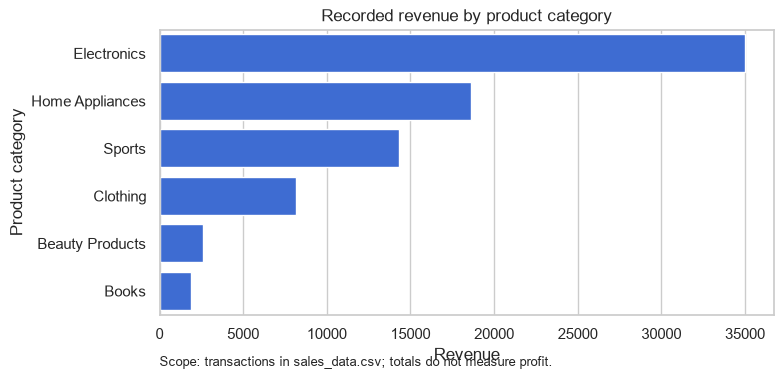

In [20]:
category_revenue = (
    sales.groupby('Product Category', as_index=False)['Total Revenue']
    .sum()
    .sort_values('Total Revenue', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=category_revenue,
    y='Product Category',
    x='Total Revenue',
    color='#2563EB',
    ax=ax
)
ax.set(title='Recorded revenue by product category', xlabel='Revenue', ylabel='Product category')
ax.text(
    0,
    -0.18,
    'Scope: transactions in sales_data.csv; totals do not measure profit.',
    transform=ax.transAxes,
    fontsize=9
)
fig.tight_layout()
plt.show()


## 18. End-to-end analysis checklist

1. State the question and observation unit.
2. Locate and document the source.
3. Inspect shape, columns, dtypes, samples, and missingness.
4. Validate keys, ranges, and required columns.
5. Clean with explicit decisions—not automatic guesses.
6. Reshape or join with row-count and key checks.
7. Calculate the smallest set of useful summaries.
8. Visualize with the chart that matches the question.
9. State scope, assumptions, and limitations.
10. Restart and run all cells to test reproducibility.


## Easy revision cheat sheet

| Concept | Question to ask | Tool |
|---|---|---|
| Observation unit | What does one row mean? | inspect source and keys |
| Tidy data | Is each variable a column? | `melt`, `pivot_table` |
| Reliable types | Does dtype match meaning? | `astype`, `to_numeric`, `to_datetime` |
| Ordered labels | Is category order meaningful? | `CategoricalDtype` |
| Text cleaning | Are spaces/case consistent? | `.str` methods |
| Group comparison | Need group value on every row? | `groupby().transform()` |
| Safe join | What key relationship is expected? | `merge(validate=..., indicator=True)` |
| Nearby time values | Need previous/moving result? | `shift`, `diff`, `rolling` |
| Readable pipeline | Can the recipe be named? | method chains and `.pipe` |
| Memory | Are repeated labels expensive? | `category`, chunking |
| Correctness | What assumption could fail? | assertions and reconciliation |
| Reproducibility | Will rerunning give the same result? | seeds, versions, run-all |
| Honest inference | Is this association or cause? | domain reasoning and design |

**Memory trick:** A trustworthy analysis is not only code that runs. It asks a precise question, preserves meaning, checks assumptions, and explains what the result cannot prove.
